In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
import random

In [2]:
# Load data
regular_season_df = pd.read_csv('../data/raw/MRegularSeasonCompactResults.csv')
tourney_df = pd.read_csv('../data/raw/MNCAATourneyCompactResults.csv')
ordinals_df = pd.read_csv('../data/raw/MMasseyOrdinals.csv')
sample_sub_df = pd.read_csv('submission.csv')

In [3]:
years_to_train = [2022, 2023, 2024, 2025]

## First Eye: Masey Matrix

In [4]:
def calculate_massey_ratings(games_df, teams_list):
    """
    Derives the Massey Ratings from a dataframe of matchups.
    games_df expects columns: ['WTeamID', 'LTeamID', 'WScore', 'LScore']
    """
    n_teams = len(teams_list)
    team_to_idx = {team: i for i, team in enumerate(teams_list)}
    
    # Initialize the Matrix M and vector y with zeros
    M = np.zeros((n_teams, n_teams))
    y = np.zeros(n_teams)
    
    # Populate the Matrix and Vector
    for _, row in games_df.iterrows():
        w_idx = team_to_idx[row['WTeamID']]
        l_idx = team_to_idx[row['LTeamID']]
        
        # Raw margin
        margin = row['WScore'] - row['LScore']
        
        # The Dampening Function (Your square root logic)
        dampened_margin = np.sqrt(margin)
        
        # Diagonal elements: Add a game played
        M[w_idx, w_idx] += 1
        M[l_idx, l_idx] += 1
        
        # Off-diagonal elements: Subtract a matchup
        M[w_idx, l_idx] -= 1
        M[l_idx, w_idx] -= 1
        
        # Update the margin vector y
        y[w_idx] += dampened_margin
        y[l_idx] -= dampened_margin
    
    # Regularization to connect isolated graph components
    alpha = 0.01
    np.fill_diagonal(M, M.diagonal() + alpha)
        
    # The "Massey Fix": Replace the last row to prevent a Singular Matrix
    M[-1, :] = 1
    y[-1] = 0
    
    # Solve the linear system: M * r = y
    ratings = np.linalg.solve(M, y)
    
    # Map ratings back to Team IDs
    massey_dict = {teams_list[i]: ratings[i] for i in range(n_teams)}
    return massey_dict

## Second Eye: Bradley Terry Model

In [5]:
from sklearn.linear_model import LogisticRegression

def calculate_bradley_terry(games_df, teams_list):
    n_teams = len(teams_list)
    team_to_idx = {team: i for i, team in enumerate(teams_list)}
    
    # We will create two rows per game so the model doesn't learn a "home/away" bias
    # purely based on who we arbitrarily assign as +1
    X = []
    y = []
    
    for _, row in games_df.iterrows():
        w_idx = team_to_idx[row['WTeamID']]
        l_idx = team_to_idx[row['LTeamID']]
        
        # Row 1: Winning team is +1, Losing team is -1. Target is 1 (Win)
        x_win = np.zeros(n_teams)
        x_win[w_idx] = 1
        x_win[l_idx] = -1
        X.append(x_win)
        y.append(1)
        
        # Row 2: Losing team is +1, Winning team is -1. Target is 0 (Loss)
        x_loss = np.zeros(n_teams)
        x_loss[l_idx] = 1
        x_loss[w_idx] = -1
        X.append(x_loss)
        y.append(0)
        
    X = np.array(X)
    y = np.array(y)
    
    # Fit Logistic Regression without an intercept (ratings should center naturally)
    # C=10.0 applies mild regularization to prevent ratings from exploding for undefeated teams
    clf = LogisticRegression(fit_intercept=False, C=10.0, solver='lbfgs')
    clf.fit(X, y)
    
    # Extract the coefficients as our BT ratings
    bt_ratings = clf.coef_[0]
    bt_dict = {teams_list[i]: bt_ratings[i] for i in range(n_teams)}
    
    return bt_dict

In [6]:
def build_ensemble_training_set(games_df, massey_dict, bt_dict, ordinals_dict):
    """
    Constructs the final X feature matrix and y target vector.
    Assumes ordinals_dict maps TeamID -> Expert Ranking (lower is better).
    """
    X = []
    y = []
    
    for _, row in games_df.iterrows():
        w_team = row['WTeamID']
        l_team = row['LTeamID']
        
        # Ensure both teams exist in all our dictionaries
        if not all(team in massey_dict and team in bt_dict and team in ordinals_dict for team in [w_team, l_team]):
            continue
            
        # Data Augmentation: Randomly assign Team A and Team B
        # If we always put the Winner as Team A, the target is always 1, and the model learns nothing.
        if random.random() > 0.5:
            team_a, team_b = w_team, l_team
            target = 1  # Team A won
        else:
            team_a, team_b = l_team, w_team
            target = 0  # Team A lost
            
        # Extract features (The Three Eyes)
        massey_diff = massey_dict[team_a] - massey_dict[team_b]
        bt_diff = bt_dict[team_a] - bt_dict[team_b]
        
        # Note: For rankings, a LOWER number is better (Rank 1 > Rank 10).
        # We calculate (B - A) so that a positive number means Team A is better.
        ordinal_diff = ordinals_dict[team_b] - ordinals_dict[team_a] 
        
        X.append([massey_diff, bt_diff, ordinal_diff])
        y.append(target)
        
    return np.array(X), np.array(y)

In [7]:
def build_master_training_set(regular_season_df, tourney_df, ordinals_df, historical_years):
    X_master = []
    y_master = []
    
    for year in historical_years:
        # 1. Isolate the temporal sandbox: Only look at THIS year
        reg_season_year = regular_season_df[regular_season_df['Season'] == year]
        tourney_year = tourney_df[tourney_df['Season'] == year]
        ordinals_year = ordinals_df[(ordinals_df['Season'] == year) & (ordinals_df['SystemName'] == 'POM')]
        
        # Extract Day 133 rankings (The final pre-tournament expert rankings)
        day_133_ordinals = ordinals_year[ordinals_year['RankingDayNum'] == 133]
        ordinals_dict = dict(zip(day_133_ordinals['TeamID'], day_133_ordinals['OrdinalRank']))
        
        # 2. Calculate the "Eyes" using ONLY the regular season
        teams_list = pd.unique(reg_season_year[['WTeamID', 'LTeamID']].values.ravel('K'))
        massey_dict = calculate_massey_ratings(reg_season_year, teams_list)
        bt_dict = calculate_bradley_terry(reg_season_year, teams_list)
        
        # 3. Train the model using the TOURNAMENT games
        # The features are from the regular season, the target is the tournament outcome
        X_year, y_year = build_ensemble_training_set(tourney_year, massey_dict, bt_dict, ordinals_dict)
        
        X_master.append(X_year)
        y_master.append(y_year)
        
    return np.vstack(X_master), np.concatenate(y_master)

# Example Usage:
# years_to_train = [2022, 2023, 2024, 2025]
# X_train, y_train = build_master_training_set(reg_df, tourney_df, ordinals_df, years_to_train)

In [8]:
def generate_kaggle_submission(sample_sub_df, ensemble_model, massey_dict, bt_dict, ordinals_dict):
    """
    Parses the Kaggle SampleSubmission file, constructs the feature differences,
    predicts the probabilities, and returns the final DataFrame.
    """
    predictions = []
    
    for _, row in sample_sub_df.iterrows():
        # Parse the Kaggle ID string (Format: YYYY_TeamA_TeamB)
        year, team_a, team_b = row['ID'].split('_')
        team_a = int(team_a)
        team_b = int(team_b)
        
        # Safe extraction: If a team is somehow missing (rare in the actual tournament),
        # we default their rating to 0 (average).
        massey_a = massey_dict.get(team_a, 0)
        massey_b = massey_dict.get(team_b, 0)
        
        bt_a = bt_dict.get(team_a, 0)
        bt_b = bt_dict.get(team_b, 0)
        
        # For ordinals, missing often means unranked (give them a bad rank, e.g., 300)
        ord_a = ordinals_dict.get(team_a, 300)
        ord_b = ordinals_dict.get(team_b, 300)
        
        # Calculate differences exactly as we did in training
        # Positive value means Team A is stronger
        massey_diff = massey_a - massey_b
        bt_diff = bt_a - bt_b
        
        # Remember: Lower ordinal rank is better. (Team B rank - Team A rank)
        ordinal_diff = ord_b - ord_a 
        
        # Construct the single row feature matrix
        X_test_row = np.array([[massey_diff, bt_diff, ordinal_diff]])
        
        # Predict probability that Team A (the first team) wins
        # predict_proba returns [[P(Class 0), P(Class 1)]]
        prob_team_a_wins = ensemble_model.predict_proba(X_test_row)[0][1]
        
        predictions.append({
            'ID': row['ID'],
            'Pred': prob_team_a_wins
        })
        
    # Convert to DataFrame and return
    submission_df = pd.DataFrame(predictions)
    return submission_df

# Example Execution:
# sub_df = pd.read_csv('SampleSubmission2026.csv')
# final_submission = generate_kaggle_submission(sub_df, ensemble_model, massey_2026, bt_2026, ordinals_2026)
# final_submission.to_csv('holy_grail_submission.csv', index=False)

In [9]:
X_train, y_train = build_master_training_set(
    regular_season_df, 
    tourney_df, 
    ordinals_df, 
    years_to_train
)

# 2. Train the Ensemble (The Holy Grail)
ensemble_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3,
    objective='binary:logistic',
    random_state=42 # Set a seed for reproducibility
)
ensemble_model.fit(X_train, y_train)

# 3. Generate the 2026 Ratings (The Current Season)
# Isolate 2026 Regular Season
reg_2026 = regular_season_df[regular_season_df['Season'] == 2026]
teams_2026 = pd.unique(reg_2026[['WTeamID', 'LTeamID']].values.ravel('K'))

# Calculate the 2026 "Eyes"
massey_2026 = calculate_massey_ratings(reg_2026, teams_2026)
bt_2026 = calculate_bradley_terry(reg_2026, teams_2026)

# Extract 2026 Day 133 Ordinals
ordinals_2026_df = ordinals_df[
    (ordinals_df['Season'] == 2026) & 
    (ordinals_df['SystemName'] == 'POM') & 
    (ordinals_df['RankingDayNum'] == 133)
]
ordinals_2026_dict = dict(zip(ordinals_2026_df['TeamID'], ordinals_2026_df['OrdinalRank']))

# 4. Generate the Final Submission File
final_submission = generate_kaggle_submission(
    sample_sub_df, 
    ensemble_model, 
    massey_2026, 
    bt_2026, 
    ordinals_2026_dict
)

# Save to disk
final_submission.to_csv('holy_grail_submission.csv', index=False)
print("Pipeline Complete. Submission saved.")

Pipeline Complete. Submission saved.


## women

In [10]:
def build_womens_training_set(games_df, massey_dict, bt_dict):
    """
    Constructs the X feature matrix using ONLY Massey and Bradley-Terry.
    """
    X = []
    y = []
    
    for _, row in games_df.iterrows():
        w_team = row['WTeamID']
        l_team = row['LTeamID']
        
        # Ensure teams exist in our math dictionaries
        if w_team not in massey_dict or l_team not in massey_dict:
            continue
            
        # Data Augmentation (Symmetry)
        if random.random() > 0.5:
            team_a, team_b = w_team, l_team
            target = 1
        else:
            team_a, team_b = l_team, w_team
            target = 0
            
        massey_diff = massey_dict[team_a] - massey_dict[team_b]
        bt_diff = bt_dict[team_a] - bt_dict[team_b]
        
        # Only TWO features now
        X.append([massey_diff, bt_diff])
        y.append(target)
        
    return np.array(X), np.array(y)

In [11]:
def generate_womens_submission(sample_sub_df, ensemble_model, massey_dict, bt_dict):
    predictions = []
    
    for _, row in sample_sub_df.iterrows():
        year, team_a, team_b = row['ID'].split('_')
        team_a, team_b = int(team_a), int(team_b)
        
        massey_diff = massey_dict.get(team_a, 0) - massey_dict.get(team_b, 0)
        bt_diff = bt_dict.get(team_a, 0) - bt_dict.get(team_b, 0)
        
        # Only TWO features
        X_test_row = np.array([[massey_diff, bt_diff]])
        
        prob_team_a_wins = ensemble_model.predict_proba(X_test_row)[0][1]
        
        predictions.append({
            'ID': row['ID'],
            'Pred': prob_team_a_wins
        })
        
    return pd.DataFrame(predictions)

# When you initialize the Women's model, use the deeper tree:
# womens_ensemble = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, objective='binary:logistic')

In [12]:
def build_womens_master_training_set(regular_season_df, tourney_df, historical_years):
    X_master = []
    y_master = []
    
    for year in historical_years:
        reg_season_year = regular_season_df[regular_season_df['Season'] == year]
        tourney_year = tourney_df[tourney_df['Season'] == year]
        
        teams_list = pd.unique(reg_season_year[['WTeamID', 'LTeamID']].values.ravel('K'))
        
        # Calculate the Two Eyes using ONLY regular season data
        massey_dict = calculate_massey_ratings(reg_season_year, teams_list)
        bt_dict = calculate_bradley_terry(reg_season_year, teams_list)
        
        # Build features using tournament outcomes
        X_year, y_year = build_womens_training_set(tourney_year, massey_dict, bt_dict)
        
        X_master.append(X_year)
        y_master.append(y_year)
        
    return np.vstack(X_master), np.concatenate(y_master)

# ==========================================
# 1. LOAD THE RAW KAGGLE DATA (Notice no Ordinals)
# ==========================================
w_regular_season_df = pd.read_csv('../data/raw/WRegularSeasonCompactResults.csv')
w_tourney_df = pd.read_csv('../data/raw/WNCAATourneyCompactResults.csv')
sample_sub_df = pd.read_csv('submission.csv') 

# Filter Sample Submission for Women's IDs ONLY (Starts with '3')
# Kaggle submissions often combine M and W into one file now.
w_sample_sub_df = sample_sub_df[sample_sub_df['ID'].str.split('_').str[1].str.startswith('3')]

# ==========================================
# 2. EXECUTE THE PIPELINE
# ==========================================
years_to_train = [2022, 2023, 2024, 2025]

# Build the strictly isolated historical training data
X_train_w, y_train_w = build_womens_master_training_set(
    w_regular_season_df, 
    w_tourney_df, 
    years_to_train
)

# Initialize the Duality Model with max_depth=5
womens_ensemble = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=5, 
    objective='binary:logistic',
    random_state=42
)
womens_ensemble.fit(X_train_w, y_train_w)

# ==========================================
# 3. GENERATE 2026 PREDICTIONS
# ==========================================
w_reg_2026 = w_regular_season_df[w_regular_season_df['Season'] == 2026]
w_teams_2026 = pd.unique(w_reg_2026[['WTeamID', 'LTeamID']].values.ravel('K'))

# Calculate the 2026 "Eyes"
w_massey_2026 = calculate_massey_ratings(w_reg_2026, w_teams_2026)
w_bt_2026 = calculate_bradley_terry(w_reg_2026, w_teams_2026)

# Generate predictions
w_final_submission = generate_womens_submission(
    w_sample_sub_df, 
    womens_ensemble, 
    w_massey_2026, 
    w_bt_2026
)

print(w_final_submission.tail(20))

                   ID      Pred
65683  2026_3475_3477  0.967630
65684  2026_3475_3478  0.967630
65685  2026_3475_3479  0.967630
65686  2026_3475_3480  0.884166
65687  2026_3475_3481  0.967630
65688  2026_3476_3477  0.023048
65689  2026_3476_3478  0.861661
65690  2026_3476_3479  0.129000
65691  2026_3476_3480  0.014444
65692  2026_3476_3481  0.407673
65693  2026_3477_3478  0.955442
65694  2026_3477_3479  0.775445
65695  2026_3477_3480  0.067033
65696  2026_3477_3481  0.955442
65697  2026_3478_3479  0.802537
65698  2026_3478_3480  0.014444
65699  2026_3478_3481  0.440992
65700  2026_3479_3480  0.014444
65701  2026_3479_3481  0.398667
65702  2026_3480_3481  0.967630


In [13]:
w_final_submission

,ID,Pred
0,2026_3101_3102,0.888979
1,2026_3101_3103,0.967630
2,2026_3101_3104,0.014444
3,2026_3101_3105,0.821951
4,2026_3101_3106,0.981228
...,...,...
65698,2026_3478_3480,0.014444
65699,2026_3478_3481,0.440992
65700,2026_3479_3480,0.014444
65701,2026_3479_3481,0.398667


In [14]:
# 1. Combine the Men's and Women's predictions
master_submission = pd.concat([final_submission, w_final_submission], ignore_index=True)

# 2. Sort by ID (Kaggle likes clean, ordered files)
master_submission = master_submission.sort_values(by='ID')

# 3. The Professional Safety Clip
# This prevents XGBoost's extreme 0.99 or 0.01 predictions from destroying your score 
# if a massive "March Madness" upset occurs.
clip_threshold = 0.025
master_submission['Pred'] = master_submission['Pred'].clip(lower=clip_threshold, upper=1-clip_threshold)

# 4. Save the final file
master_submission.to_csv('2026_Kaggle_Master_Submission.csv', index=False)

print("Sprint Complete. File ready for upload.")

Sprint Complete. File ready for upload.


In [15]:
from sklearn.metrics import log_loss

In [16]:
def evaluate_trust(tourney_df, universal_preds_df, holygrail_preds_df, test_year=2025):
    """
    Grades two distinct models against the actual historical tournament results.
    """
    # 1. Isolate the actual outcomes for the test year
    actuals = tourney_df[tourney_df['Season'] == test_year].copy()
    
    # 2. Format actuals into Kaggle's ID structure
    # Team 1 is ALWAYS the lower ID. 
    actuals['Team1'] = actuals[['WTeamID', 'LTeamID']].min(axis=1)
    actuals['Team2'] = actuals[['WTeamID', 'LTeamID']].max(axis=1)
    
    # 3. Determine the Target (1 if Team 1 won, 0 if Team 1 lost)
    actuals['Target'] = (actuals['Team1'] == actuals['WTeamID']).astype(int)
    actuals['ID'] = actuals['Season'].astype(str) + '_' + actuals['Team1'].astype(str) + '_' + actuals['Team2'].astype(str)
    
    # 4. Merge the actual targets with your predictions
    # We use 'inner' join to ensure we only evaluate games where we have predictions
    eval_df = actuals[['ID', 'Target']].merge(universal_preds_df, on='ID', how='inner')
    eval_df = eval_df.rename(columns={'Pred': 'Pred_Universal'})
    
    eval_df = eval_df.merge(holygrail_preds_df, on='ID', how='inner')
    eval_df = eval_df.rename(columns={'Pred': 'Pred_HolyGrail'})
    
    # 5. Calculate the Log-Loss (The Kaggle Score)
    ll_universal = log_loss(eval_df['Target'], eval_df['Pred_Universal'])
    ll_holygrail = log_loss(eval_df['Target'], eval_df['Pred_HolyGrail'])
    
    # 6. The Blended Ensemble (Testing a 50/50 average)
    eval_df['Pred_Blend'] = (eval_df['Pred_Universal'] + eval_df['Pred_HolyGrail']) / 2.0
    ll_blend = log_loss(eval_df['Target'], eval_df['Pred_Blend'])
    
    print(f"--- {test_year} Out-of-Sample Validation ---")
    print(f"Universal (Linear) Log-Loss:  {ll_universal:.5f}")
    print(f"Holy Grail (Tree) Log-Loss:   {ll_holygrail:.5f}")
    print(f"50/50 Blended Log-Loss:       {ll_blend:.5f}")
    print(f"----------------------------------------")
    
    return eval_df

In [17]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import log_loss

# ==========================================
# 1. TRAIN THE TIME MACHINE MODEL (2022 - 2024)
# ==========================================
print("Training 2025 Validation Model...")
X_train_val, y_train_val = build_master_training_set(
    regular_season_df, 
    tourney_df, 
    ordinals_df, 
    [2022, 2023, 2024] # Strictly NO 2025 data
)

val_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    objective='binary:logistic',
    random_state=42
)
val_model.fit(X_train_val, y_train_val)

# ==========================================
# 2. GENERATE 2025 PREDICTIONS
# ==========================================
# Isolate 2025 Regular Season
reg_2025 = regular_season_df[regular_season_df['Season'] == 2025]
teams_2025 = pd.unique(reg_2025[['WTeamID', 'LTeamID']].values.ravel('K'))

# Calculate 2025 Eyes
massey_2025 = calculate_massey_ratings(reg_2025, teams_2025)
bt_2025 = calculate_bradley_terry(reg_2025, teams_2025)

# Extract 2025 Day 133 Ordinals
ordinals_2025_df = ordinals_df[
    (ordinals_df['Season'] == 2025) & 
    (ordinals_df['SystemName'] == 'POM') & 
    (ordinals_df['RankingDayNum'] == 133)
]
ordinals_2025_dict = dict(zip(ordinals_2025_df['TeamID'], ordinals_2025_df['OrdinalRank']))

# Get actual 2025 Tournament matchups to predict
tourney_2025 = tourney_df[tourney_df['Season'] == 2025].copy()
tourney_2025['Team1'] = tourney_2025[['WTeamID', 'LTeamID']].min(axis=1)
tourney_2025['Team2'] = tourney_2025[['WTeamID', 'LTeamID']].max(axis=1)
tourney_2025['ID'] = '2025_' + tourney_2025['Team1'].astype(str) + '_' + tourney_2025['Team2'].astype(str)

# Generate predictions for the actual games played
hg_preds_2025 = generate_kaggle_submission(
    tourney_2025[['ID']], # Pass just the IDs formatted properly
    val_model, 
    massey_2025, 
    bt_2025, 
    ordinals_2025_dict
)

# ==========================================
# 3. GRADE THE EXAM (Using the evaluate_trust function)
# ==========================================
print("Evaluating Trust...")
# If you don't have universal_2025_df in memory right now, 
# you can comment this out and just check the hg_preds_2025 log loss manually:
# actual_targets = (tourney_2025['Team1'] == tourney_2025['WTeamID']).astype(int)
# print(f"Holy Grail 2025 Log-Loss: {log_loss(actual_targets, hg_preds_2025['Pred']):.5f}")

try:
    results_df = evaluate_trust(tourney_df, universal_2025_df, hg_preds_2025, test_year=2025)
except NameError:
    print("Universal 2025 predictions not found in memory. Evaluating Holy Grail only.")
    actual_targets = (tourney_2025['Team1'] == tourney_2025['WTeamID']).astype(int)
    print(f"Holy Grail (Tree) Log-Loss: {log_loss(actual_targets, hg_preds_2025['Pred']):.5f}")

Training 2025 Validation Model...
Evaluating Trust...
Universal 2025 predictions not found in memory. Evaluating Holy Grail only.
Holy Grail (Tree) Log-Loss: 0.51772


In [30]:
# 1. Get the importance scores
importances = val_model.feature_importances_
feature_names = ["Matrix_Eye", "Probabilistic_Eye", "Expert_Eye"]

# 2. Create a clean display
feature_importance_df = pd.DataFrame({
    'Eye': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- The Brain of the Holy Grail ---")
print(feature_importance_df)

--- The Brain of the Holy Grail ---
                 Eye  Importance
0         Matrix_Eye    0.440414
1  Probabilistic_Eye    0.304066
2         Expert_Eye    0.255520


In [18]:
universal_2025_df = pd.read_csv('submission_2026_v2_universal.csv')

In [20]:
# 1. Clean the Men's submission (Keep ONLY IDs where the first team starts with '1' or '2')
clean_mens_submission = final_submission[final_submission['ID'].str.split('_').str[1].str.startswith(('1', '2'))]

# 2. Combine the cleaned Men's and the correct Women's predictions
master_submission = pd.concat([clean_mens_submission, w_final_submission], ignore_index=True)

# 3. Sort by ID 
master_submission = master_submission.sort_values(by='ID')

# 4. Apply the Professional Safety Clip
clip_threshold = 0.025
master_submission['Pred'] = master_submission['Pred'].clip(lower=clip_threshold, upper=1-clip_threshold)

# 5. Save the final file
master_submission.to_csv('2026_Kaggle_Master_Submission_Fixed.csv', index=False)

print(f"Total rows in final file: {len(master_submission)}")

Total rows in final file: 132133


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confidence_heatmap(submission_df, title="Model Confidence Heatmap"):
    """
    Visualizes the distribution of predictions. 
    Concentration at the edges (0 and 1) means an aggressive model.
    Concentration in the middle (0.5) means a conservative model.
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(submission_df['Pred'], bins=30, kde=True, color='teal')
    
    plt.axvline(0.5, color='red', linestyle='--', label='Coin Flip (0.5)')
    plt.title(f"{title}: 2026 Tournament Distribution")
    plt.xlabel("Predicted Probability (Team A wins)")
    plt.ylabel("Number of Matchups")
    plt.legend()
    plt.show()

# Run this on your final 2026 submission
# plot_confidence_heatmap(master_submission, "Holy Grail 2026")

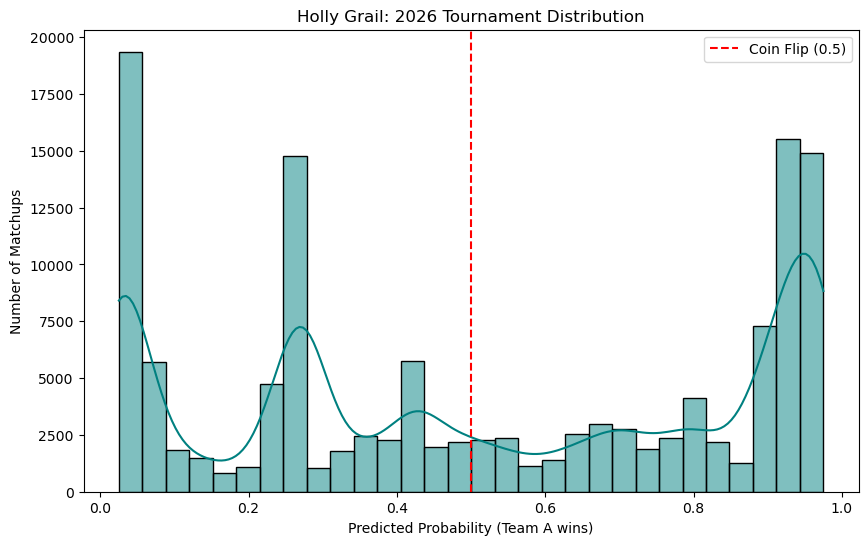

In [ ]:
plot_confidence_heatmap(master_submission, "Holly Grail")

In [22]:
def find_hot_takes(submission_df, top_n=5):
    """
    Identifies the most confident (extreme) predictions 
    and the most uncertain (near 0.5) predictions.
    """
    # Confident for Team A
    favorites = submission_df.sort_values(by='Pred', ascending=False).head(top_n)
    
    # Confident for Team B (Underdogs according to ID order)
    underdogs = master_submission.sort_values(by='Pred', ascending=True).head(top_n)
    
    # The "Toss-ups"
    toss_ups = master_submission.iloc[(submission_df['Pred'] - 0.5).abs().argsort()[:top_n]]
    
    print("--- THE MODEL'S TOP FAVORITES ---")
    print(favorites[['ID', 'Pred']])
    print("\n--- THE MODEL'S BIGGEST UNDERDOGS ---")
    print(underdogs[['ID', 'Pred']])
    print("\n--- THE COIN FLIPS (TOSS-UPS) ---")
    print(toss_ups[['ID', 'Pred']])

# Run it
# find_hot_takes(master_submission)

In [23]:
find_hot_takes(master_submission)

--- THE MODEL'S TOP FAVORITES ---
                    ID   Pred
117418  2026_3301_3473  0.975
122916  2026_3339_3443  0.975
112983  2026_3276_3439  0.975
122917  2026_3339_3444  0.975
120694  2026_3323_3362  0.975

--- THE MODEL'S BIGGEST UNDERDOGS ---
                    ID   Pred
118517  2026_3309_3392  0.025
118529  2026_3309_3404  0.025
118528  2026_3309_3403  0.025
118527  2026_3309_3402  0.025
118526  2026_3309_3401  0.025

--- THE COIN FLIPS (TOSS-UPS) ---
                   ID      Pred
16718  2026_1156_1217  0.500093
16671  2026_1156_1168  0.500093
20724  2026_1169_1219  0.500093
49300  2026_1288_1368  0.500093
47920  2026_1281_1301  0.500093


In [26]:
import pandas as pd

# 1. Load both Name Mapping files
m_teams = pd.read_csv('../data/raw/MTeams.csv')
w_teams = pd.read_csv('../data/raw/WTeams.csv')

# 2. Combine them into one master Dictionary
# We only need TeamID and TeamName
all_teams = pd.concat([
    m_teams[['TeamID', 'TeamName']], 
    w_teams[['TeamID', 'TeamName']]
], ignore_index=True)

team_name_map = dict(zip(all_teams['TeamID'], all_teams['TeamName']))

# 3. Create a human-readable version of the master submission
def humanize_submission(df, name_map):
    # Split the 'ID' column (e.g., "2026_1101_1102" -> ["2026", "1101", "1102"])
    ids_split = df['ID'].str.split('_', expand=True)
    
    # Convert IDs to integers for mapping
    team_a_ids = ids_split[1].astype(int)
    team_b_ids = ids_split[2].astype(int)
    
    # Map the names
    readable_df = pd.DataFrame({
        'ID': df['ID'],
        'Team_A': team_a_ids.map(name_map),
        'Team_B': team_b_ids.map(name_map),
        'Win_Prob_A': df['Pred']
    })
    
    return readable_df

# Execute the mapping
readable_submission = humanize_submission(master_submission, team_name_map)

# Look at a slice of the Women's bracket (IDs starting with 3)
print(readable_submission[readable_submission['ID'].str.contains('_3')].tail(10))

                    ID          Team_A        Team_B  Win_Prob_A
132123  2026_3477_3478  East Texas A&M      Le Moyne    0.955442
132124  2026_3477_3479  East Texas A&M    Mercyhurst    0.775445
132125  2026_3477_3480  East Texas A&M  West Georgia    0.067033
132126  2026_3477_3481  East Texas A&M     New Haven    0.955442
132127  2026_3478_3479        Le Moyne    Mercyhurst    0.802537
132128  2026_3478_3480        Le Moyne  West Georgia    0.025000
132129  2026_3478_3481        Le Moyne     New Haven    0.440992
132130  2026_3479_3480      Mercyhurst  West Georgia    0.025000
132131  2026_3479_3481      Mercyhurst     New Haven    0.398667
132132  2026_3480_3481    West Georgia     New Haven    0.967630


In [27]:
readable_submission.head(10)

,ID,Team_A,Team_B,Win_Prob_A
0,2026_1101_1102,Abilene Chr,Air Force,0.755843
1,2026_1101_1103,Abilene Chr,Akron,0.238075
2,2026_1101_1104,Abilene Chr,Alabama,0.279905
3,2026_1101_1105,Abilene Chr,Alabama A&M,0.561510
4,2026_1101_1106,Abilene Chr,Alabama St,0.716704
5,2026_1101_1107,Abilene Chr,SUNY Albany,0.807298
6,2026_1101_1108,Abilene Chr,Alcorn St,0.902750
7,2026_1101_1110,Abilene Chr,American Univ,0.411939
8,2026_1101_1111,Abilene Chr,Appalachian St,0.419621
9,2026_1101_1112,Abilene Chr,Arizona,0.279905


In [ ]:
readable_submission['Team_A']=="Duke"

0         False
1         False
2         False
3         False
4         False
          ...  
132128    False
132129    False
132130    False
132131    False
132132    False
Name: Team_A, Length: 132133, dtype: bool

In [ ]:
# 1. Identify the Team Names (using partial strings to be safe)
# This searches for any name containing "Duke" or "Siena"
target_a = "Duke"
target_b = "Siena"

# 2. Apply the Filter
# We search for rows where A is Duke AND B is Siena, OR vice versa
matchup = readable_submission[
    (readable_submission['Team_A'].str.contains(target_a) & readable_submission['Team_B'].str.contains(target_b)) |
    (readable_submission['Team_A'].str.contains(target_b) & readable_submission['Team_B'].str.contains(target_a))
]

print(matchup)

                   ID Team_A Team_B  Win_Prob_A
24420  2026_1181_1373   Duke  Siena    0.895658
90413  2026_3181_3373   Duke  Siena    0.975000


In [28]:
readable_submission.to_csv('ncaa_2026_data.csv', index=False)